<a href="https://colab.research.google.com/github/ekatet19915-cpu/3D_model/blob/main/3Dmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
readme = """# Plausible 3D model from a single photo

University project (topic 04/11): textured 3D model from one photograph.
Reconstruction runs in Google Colab (GPU), the rest can run locally on CPU.

> **SK:** Školský projekt (téma 04/11): textúrovaný 3D model z jednej fotografie.
> Rekonštrukcia beží v Google Colabe (GPU), zvyšok sa dá robiť lokálne.

## Interface agreements (`src/pipeline.py`)

| Function | Input | Output |
|---|---|---|
| `remove_background(img)` | PIL RGB/RGBA | PIL RGBA |
| `prepare_input(img)` | PIL RGBA | PIL RGB 512x512, centered, gray background |
| `reconstruct(img, model="triposr" or "sf3d")` | PIL RGB | `trimesh.Trimesh` |
| `postprocess(mesh)` | `trimesh.Trimesh` | `trimesh.Trimesh` |
| `export(mesh, path)` | `trimesh.Trimesh`, path without extension | `.glb` and `.obj` |

## Rules
- Reconstruction (CUDA) runs only in Colab.
- Heavy files (GLB, OBJ, MP4) stay on Google Drive, not in Git.
- `git pull` before work, commit and push after. Names and commits in English.
- Notebooks: `A_name.ipynb` / `B_name.ipynb`.

> **SK:** Pred prácou `git pull`, po práci commit a push. Názvy súborov a commity po anglicky.
> Ťažké súbory patria na Google Drive, nie do Gitu.
"""
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

sync("Add README with interface agreements")

$ git pull --rebase --autostash
Already up to date.

$ git commit -m "Add README with interface agreements"
[main 7259b99] Add README with interface agreements
 1 file changed, 26 insertions(+), 2 deletions(-)

$ git push
To https://github.com/ekatet19915-cpu/3D_model.git
   5ba4f15..7259b99  main -> main



In [10]:
sync("Add test photos, update .gitignore")

$ git pull --rebase --autostash
Already up to date.

$ git commit -m "Add test photos, update .gitignore"
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

$ git push
Everything up-to-date



In [9]:
gitignore = """# Python
__pycache__/
*.pyc
.ipynb_checkpoints/

# Heavy outputs live on Google Drive, not in Git
outputs/*.glb
outputs/*.obj
outputs/*.mp4
outputs/*.gif

# Secrets
.env
*token*
"""
with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

sync("Add test photos, update .gitignore")

$ git pull --rebase --autostash
Already up to date.

$ git commit -m "Add test photos, update .gitignore"
[main 5ba4f15] Add test photos, update .gitignore
 30 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 data/test/hard_01.jpg
 create mode 100644 data/test/hard_02.jpg
 create mode 100644 data/test/hard_03.jpg
 create mode 100644 data/test/hard_04.jpg
 create mode 100644 data/test/medium_01.jpg
 create mode 100644 data/test/medium_02.jpg
 create mode 100644 data/test/medium_03.jpg
 create mode 100644 data/test/medium_04.jpg
 create mode 100644 data/test/medium_05.jpg
 create mode 100644 data/test/simple_01.jpg
 create mode 100644 data/test/simple_02.jpg
 create mode 100644 data/test/simple_03.jpg
 create mode 100644 data/test/simple_04.jpg
 create mode 100644 data/test/simple_05.jpg
 create mode 100644 data/test/simple_06.jpg
 create mode 100644 foto-bed-simple.webp
 create mode 100644 foto-bird-hard.jpg
 create mode 100644 foto-bottle-medium.jpeg
 create mode 1006

simple 6
medium 5
hard 4


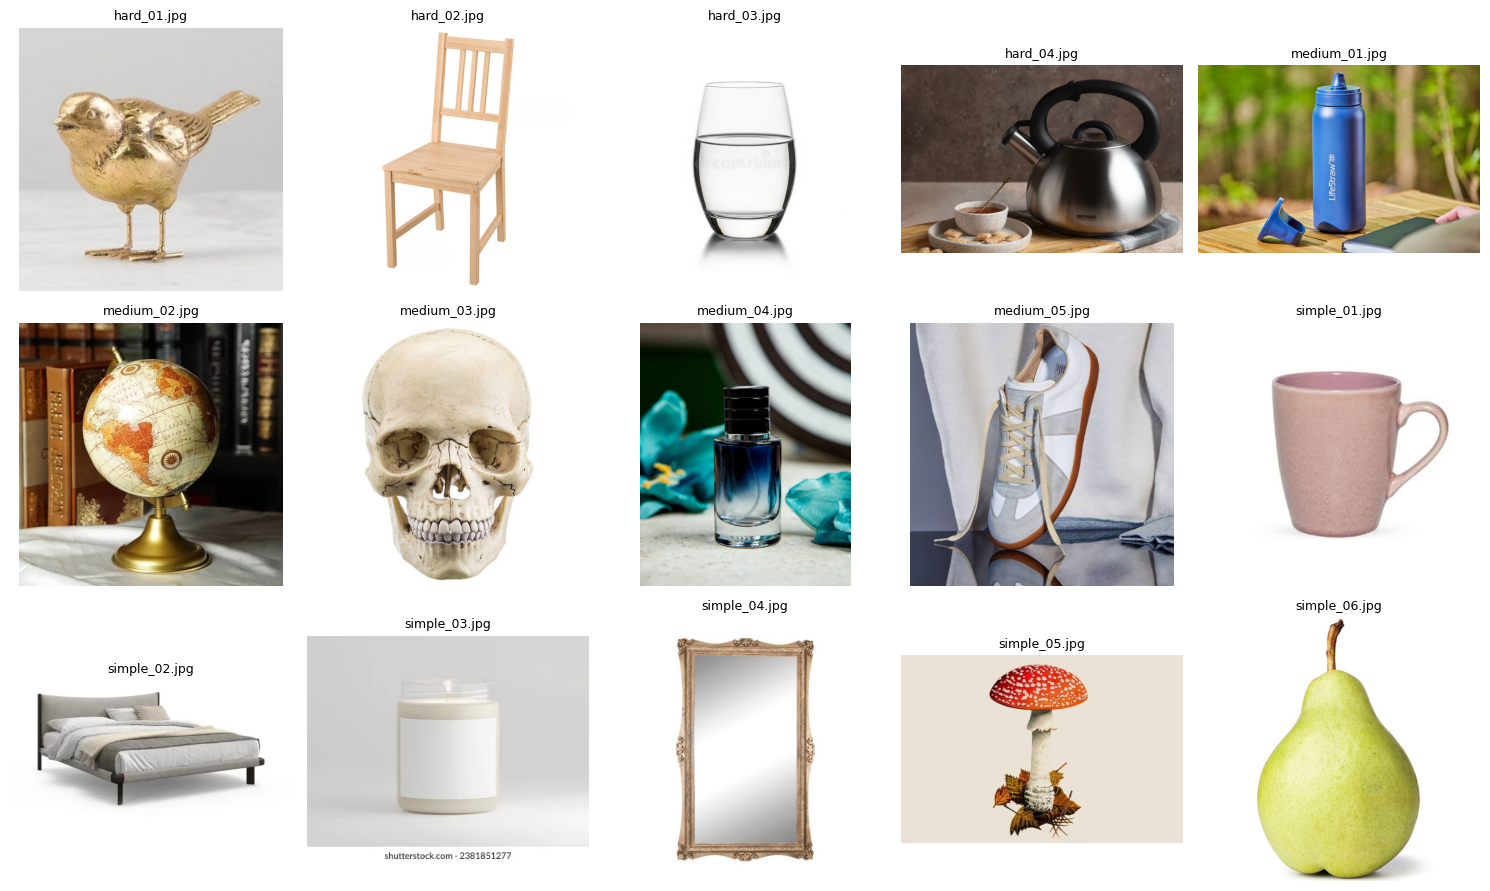

In [8]:
for c in ["simple", "medium", "hard"]:
    print(c, len(glob.glob(f"{TEST_DIR}/{c}_*.jpg")))

import matplotlib.pyplot as plt
paths = sorted(glob.glob(f"{TEST_DIR}/*.jpg"))
fig, axs = plt.subplots(3, 5, figsize=(15, 9))
for ax, p in zip(axs.flat, paths):
    ax.imshow(Image.open(p)); ax.set_title(os.path.basename(p), fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [7]:
add_photos("hard")

Saving foto-bird-hard.jpg to foto-bird-hard.jpg
Saving foto-chair-simple.avif to foto-chair-simple.avif
Saving foto-cup-hard.webp to foto-cup-hard.webp
Saving foto-tepoot-hard.jpg to foto-tepoot-hard.jpg
foto-bird-hard.jpg -> data/test/hard_01.jpg (447, 447)
foto-chair-simple.avif -> data/test/hard_02.jpg (1024, 1024)
foto-cup-hard.webp -> data/test/hard_03.jpg (800, 800)
foto-tepoot-hard.jpg -> data/test/hard_04.jpg (1024, 683)


In [6]:
add_photos("medium")

Saving foto-bottle-medium.jpeg to foto-bottle-medium.jpeg
Saving foto-glo-medium.jpg to foto-glo-medium.jpg
Saving foto-head-medium.jpg to foto-head-medium.jpg
Saving foto-parfum-medium.avif to foto-parfum-medium.avif
Saving foto-sneaker-medium.jpg to foto-sneaker-medium.jpg
foto-bottle-medium.jpeg -> data/test/medium_01.jpg (1024, 683)
foto-glo-medium.jpg -> data/test/medium_02.jpg (447, 447)
foto-head-medium.jpg -> data/test/medium_03.jpg (432, 612)
foto-parfum-medium.avif -> data/test/medium_04.jpg (501, 626)
foto-sneaker-medium.jpg -> data/test/medium_05.jpg (554, 554)


In [5]:
add_photos("simple")

Saving foto_cup-pink.jpg to foto_cup-pink.jpg
Saving foto-bed-simple.webp to foto-bed-simple.webp
Saving foto-candel-white.webp to foto-candel-white.webp
Saving foto-mirror-simple.jpg to foto-mirror-simple.jpg
Saving foto-mushroom-simple.jpg to foto-mushroom-simple.jpg
Saving foto-pear-simple.png to foto-pear-simple.png
foto_cup-pink.jpg -> data/test/simple_01.jpg (447, 447)
foto-bed-simple.webp -> data/test/simple_02.jpg (680, 332)
foto-candel-white.webp -> data/test/simple_03.jpg (347, 280)
foto-mirror-simple.jpg -> data/test/simple_04.jpg (612, 612)
foto-mushroom-simple.jpg -> data/test/simple_05.jpg (678, 452)
foto-pear-simple.png -> data/test/simple_06.jpg (600, 600)


In [4]:
from google.colab import files
from PIL import Image, ImageOps

TEST_DIR = "data/test"
os.makedirs(TEST_DIR, exist_ok=True)

def add_photos(category):
    """Upload photos, convert to JPEG (max 1024 px), save as <category>_NN.jpg"""
    up = files.upload()
    n = len(glob.glob(f"{TEST_DIR}/{category}_*.jpg"))
    for name, data in up.items():
        tmp = f"/content/{name}"
        with open(tmp, "wb") as f:
            f.write(data)
        img = ImageOps.exif_transpose(Image.open(tmp)).convert("RGB")
        img.thumbnail((1024, 1024))
        n += 1
        out = f"{TEST_DIR}/{category}_{n:02d}.jpg"
        img.save(out, quality=92)
        os.remove(tmp)
        print(name, "->", out, img.size)

In [3]:
import glob
print(len(glob.glob("data/test/*.jpg")), "photos")
print(os.listdir("."))
run("git log --oneline -5")
run("git status --short")

0 photos
['notebooks', 'src', '.gitignore', '.git', 'outputs', 'app', 'data', 'docs', 'README.md']
$ git log --oneline -5
ca8718b Update .gitignore
d3e1563 Initial project structure
f63cf7b Initial commit



CompletedProcess(args='git status --short', returncode=0, stdout='', stderr='')

In [2]:
from google.colab import userdata
import subprocess, os

GH_USER = "ekatet19915-cpu"
REPO    = "3D_model"
NAME    = "Kate"
EMAIL   = "ekatet19915@gmail.com"

token = userdata.get("GH_TOKEN").strip()
REPO_DIR = f"/content/{REPO}"

def run(cmd, show=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, "***")
    if show and out.strip():
        print(f"$ {cmd.replace(token, '***')}\n{out}")
    return r

if not os.path.exists(REPO_DIR):
    r = run(f"git clone https://{token}@github.com/{GH_USER}/{REPO}.git {REPO_DIR}")
    if r.returncode != 0:
        raise RuntimeError("Clone failed, see message above")

os.chdir(REPO_DIR)
run(f'git config user.name "{NAME}"', show=False)
run(f'git config user.email "{EMAIL}"', show=False)

def sync(msg="Update from Colab"):
    """Pull others' changes, then commit and push ours."""
    os.chdir(REPO_DIR)
    run("git pull --rebase --autostash")
    run("git add -A")
    run(f'git commit -m "{msg}"')
    run("git push")

print("Ready. Working folder:", os.getcwd())

$ git clone https://***@github.com/ekatet19915-cpu/3D_model.git /content/3D_model
Cloning into '/content/3D_model'...

Ready. Working folder: /content/3D_model


In [1]:
sync("Add TripoSR test results")

NameError: name 'sync' is not defined

In [ ]:
sync("Update .gitignore")

$ git pull --rebase --autostash
Already up to date.

$ git commit -m "Update .gitignore"
[main ca8718b] Update .gitignore
 1 file changed, 7 insertions(+), 1 deletion(-)

$ git push
To https://github.com/ekatet19915-cpu/3D_model.git
   d3e1563..ca8718b  main -> main



In [ ]:
import os
os.chdir(REPO_DIR)

gitignore = """# Python
__pycache__/
*.pyc
.ipynb_checkpoints/

# Heavy outputs live on Google Drive, not in Git
outputs/*.glb
outputs/*.obj
outputs/*.mp4
outputs/*.gif

# Secrets
.env
*token*
"""
with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

In [ ]:
import os
os.chdir(REPO_DIR)

for d in ["data/test", "src", "notebooks", "outputs", "app", "docs"]:
    os.makedirs(d, exist_ok=True)
    open(f"{d}/.gitkeep", "a").close()

with open(".gitignore", "a") as f:
    f.write("\n# Тяжёлые результаты храним вне Git\noutputs/*.glb\noutputs/*.obj\noutputs/*.mp4\noutputs/*.gif\n.env\n*token*\n")

sync("Initial project structure")

$ git pull --rebase --autostash
Already up to date.

$ git commit -m "Initial project structure"
[main d3e1563] Initial project structure
 7 files changed, 8 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 app/.gitkeep
 create mode 100644 data/test/.gitkeep
 create mode 100644 docs/.gitkeep
 create mode 100644 notebooks/.gitkeep
 create mode 100644 outputs/.gitkeep
 create mode 100644 src/.gitkeep

$ git push
To https://github.com/ekatet19915-cpu/3D_model.git
   f63cf7b..d3e1563  main -> main



In [ ]:
from google.colab import userdata
import subprocess, os

GH_USER = "ekatet19915-cpu"
REPO    = "3D_model"
NAME    = "Kate"
EMAIL   = "ekatet19915@gmail.com"

token = userdata.get("GH_TOKEN").strip()
REPO_DIR = f"/content/{REPO}"

def run(cmd, show=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, "***")
    if show and out.strip():
        print(f"$ {cmd.replace(token, '***')}\n{out}")
    return r

# Клонируем, если папки ещё нет
if not os.path.exists(REPO_DIR):
    r = run(f"git clone https://{token}@github.com/{GH_USER}/{REPO}.git {REPO_DIR}")
    if r.returncode != 0:
        raise RuntimeError("Клонирование не удалось, смотрите сообщение выше")

os.chdir(REPO_DIR)
run(f'git config user.name "{NAME}"', show=False)
run(f'git config user.email "{EMAIL}"', show=False)

def sync(msg="Update from Colab"):
    """Подтянуть чужие изменения и отправить свои."""
    os.chdir(REPO_DIR)
    run("git pull --rebase --autostash")
    run("git add -A")
    run(f'git commit -m "{msg}"')
    run("git push")

print("Готово. Рабочая папка:", os.getcwd())

$ git clone https://***@github.com/ekatet19915-cpu/3D_model.git /content/3D_model
Cloning into '/content/3D_model'...

Готово. Рабочая папка: /content/3D_model


In [ ]:
from google.colab import userdata
import subprocess

GH_USER = "ekatet19915-cpu"
REPO    = "photo-to-3d"

token = userdata.get("GH_TOKEN")
print("Токен получен, длина:", len(token))

r = subprocess.run(
    f"git clone https://{token}@github.com/{GH_USER}/{REPO}.git /content/{REPO}",
    shell=True, capture_output=True, text=True
)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr.replace(token, "***"))

Токен получен, длина: 93
STDOUT: 
STDERR: Cloning into '/content/photo-to-3d'...
remote: Repository not found.
fatal: repository 'https://github.com/ekatet19915-cpu/photo-to-3d.git/' not found



In [ ]:
from google.colab import userdata
import subprocess, os

GH_USER = "ekatet19915-cpu"
REPO    = "photo-to-3d"
NAME    = "Kate"
EMAIL   = "ekatet19915@gmail.com"

token = userdata.get("GH_TOKEN")

if not os.path.exists(f"/content/{REPO}"):
    subprocess.run(f"git clone https://{token}@github.com/{GH_USER}/{REPO}.git /content/{REPO}", shell=True)

os.chdir(f"/content/{REPO}")
subprocess.run(f'git config user.name "{NAME}"', shell=True)
subprocess.run(f'git config user.email "{EMAIL}"', shell=True)

def sync(msg="Update from Colab"):
    """Подтянуть чужие изменения и отправить свои."""
    for cmd in ["git pull --rebase --autostash",
                "git add -A",
                f'git commit -m "{msg}"',
                "git push"]:
        r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        print(f"$ {cmd}\n{r.stdout}{r.stderr}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/photo-to-3d'

In [ ]:
!nvidia-smi

Thu Oct  1 11:31:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----